# Deep Learning Assignment 3 - Part 1

##  Text Generation

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# *Imports*

In [2]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,TensorDataset
from google.colab import files
import os
import random

## *Study the data:*

### Load the CSV:

we will start by loading the Songs CSV file into Dataframe using pandas and showcase a couple of rows from it.





In [3]:
# Load the data from the csv file
data_path='/content/drive/MyDrive/Songs.csv'
data=pd.read_csv(data_path, encoding='utf-8')
print(data.head(n=10))# Display the first 10 rows of the data

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

         Artist                     Title  \
0  Taylor Swift                  cardigan   
1  Taylor Swift                     exile   
2  Taylor Swift                     Lover   
3  Taylor Swift                     the 1   
4  Taylor Swift  Look What You Made Me Do   
5  Taylor Swift                     betty   
6  Taylor Swift                    august   
7  Taylor Swift                  End Game   
8  Taylor Swift     You Need To Calm Down   
9  Taylor Swift                       ME!   

                                              Lyrics  
0  Vintage tee, brand new phone\nHigh heels on co...  
1  I can see you standing, honey\nWith his arms a...  
2  We could leave the Christmas lights up 'til Ja...  
3  I'm doing good, I'm on some new shit\nBeen say...  
4  I don't like your little games\nDon't like you...  
5  Betty, I won't make assumptions\nAbout why you...  
6  Salt air, and the rust on your door\nI never n...  
7  I wanna be your end game\nI wanna be your firs...  
8  You ar

1) we will print all of the artist's names and show how many songs are associated with each artists

In [4]:
# count the number of songs assoicated for each artist
artist_song_counts=data['Artist'].value_counts()

for artist, count in artist_song_counts.items():

  print(f"{artist}: {count} songs")

Taylor Swift: 50 songs
Billie Eilish: 50 songs
David Bowie: 50 songs
Billy Joel: 50 songs
Eric Clapton: 50 songs
Leonard Cohen: 50 songs
Bruce Springsteen: 40 songs
The Beatles: 35 songs
Vance Joy: 30 songs
Bryan Adams: 30 songs
Lana Del Rey: 30 songs
Nat King Cole: 30 songs
​twenty one pilots: 30 songs
Elton John: 30 songs
Ray LaMontagne: 30 songs
John Denver: 30 songs
Frank Sinatra: 30 songs
George Michael: 30 songs
Queen: 30 songs
Ed Sheeran: 20 songs
Bob Dylan: 20 songs


2)  We will print the size of the dataset and how many songs are there.

In [5]:
data_size=data.shape

print(f"The size of the dataset is {data_size} \n")
print(f"The number of rows in the dataset is {data_size[0]} \n")
print(f"The number of columns in the dataset is {data_size[1]} \n")

songs_num= len(data)

print(f"The number of songs in the dataset is {songs_num}")



The size of the dataset is (745, 3) 

The number of rows in the dataset is 745 

The number of columns in the dataset is 3 

The number of songs in the dataset is 745


3) We will print the average number of characters and words of a song for all songs lyrics in the dataset ( the average length of a song).



In [6]:
total_char=0
total_words=0


filtered_data=data.dropna(subset=['Lyrics'])

for lyrics in filtered_data['Lyrics']:

  total_char+=len(lyrics)
  total_words+=len(lyrics.split())

avg_char=total_char/songs_num
avg_word=total_words/songs_num


print(f"The average number of characters per song : {avg_char} \n")
print(f"The average number of words per song : {avg_word} \n")

The average number of characters per song : 1403.3476510067114 

The average number of words per song : 276.26040268456376 



4)  We will print the top 3 most used words in the congs and visualize the data using word cloud image .

The Top 3 most used words is:

the : 7458 times 

I : 6719 times 

you : 5475 times 



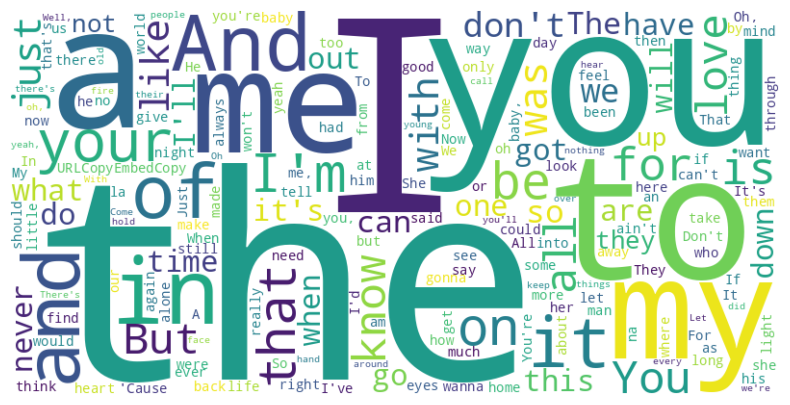

In [7]:

all_lyrics=' '.join(data['Lyrics'].tolist())
all_words=all_lyrics.split()
words_counts=Counter(all_words)

# get the top 3 used words
top_3_words=words_counts.most_common(3)

# print the top 3 used words
print("The Top 3 most used words is:\n")
for word, count in top_3_words:

  print(f"{word} : {count} times \n")


# Display the word cloud

word_cloud=WordCloud(width=800, height =400 , background_color='white').generate_from_frequencies(words_counts)

plt.figure(figsize=(10,5))
plt.imshow(word_cloud , interpolation='bilinear')
plt.axis('off')
plt.show()






# *Preprocessing:*  

**STEP 1 : Cleaning the Data :** <br>

We add the function preprocess_data(text) to clean the text by :<br>
- Convert all the lyrics to lowercase to ensure uniformity.
- Removing unnecessary symbols and keep only English letters , whitespaces and new lines.
- Normalize whitespace by collapsing multiple newlines into one and trimming extra spaces.

- Note: By examining the dataset , we notice that at the end of many song lyric, the words : "urlcopyembedcopy" and "embedshare" frequently appear. These words are not part of the actual lyrics and appear due to copy-paste issues , so we also remove them during preprocessing.

**STEP 2: Build the Vocabulary :**<BR>

- We start by tokenization all the songs lyric after cleaning , we use a regular expression (\S+|\n) that split the text into tokens. This regex is designed to capture words and newlines as seperate tokens (to preserve the structure of the songs lyrics).

- we count the occurrences of each unique tokens and build a vocabulary that includes all unique tokens and add special tokens such as "<UNK\>" (for unknown words) and "<PAD\>" (for padding).<br>Then , we sort the vocabulary alphabetically.


**STEP 3: Create Mappings for tokens:**<br>
- we create two dictionaries:<br>
1) word_to_index: maps each word from the vocabulary to a unique index.<br>
2) index_to_word: maps each index back to its corresponding word. <br>















In [13]:
def preprocess_data(text):

  if isinstance(text,str):
      text=text.lower()
      # keep only letters and spaces, and newlines
      text=re.sub(r"[^a-z'\s\n]","",text)
      # remove unwanted artifacts
      text = re.sub(r"urlcopyembedcopy|embedshare", "", text)
      # replase multiple newlines into a single new line
      text=re.sub(r"\n+","\n",text)
      # remove extra spaces (except newlines)
      text=re.sub(r"[^\S\n]+"," ",text).strip()
      # return none for empty strings
      return text if text else  None
  return None


#Step 1: clean the data
data["Prepocessed_Lyrics"]=data["Lyrics"].apply(preprocess_data)

# Drop NaN/None entries and empty strings
data["Prepocessed_Lyrics"]=data["Prepocessed_Lyrics"].dropna()



#Step 2: Build vocabulary
all_tokens = []
for lyrics in data["Prepocessed_Lyrics"]:
    if not isinstance(lyrics, str):
        continue  # Skip invalid entries
    tokens = re.findall(r"\S+|\n", lyrics)
    all_tokens.extend(tokens)

word_counts = Counter(all_tokens)
vocab = list(word_counts.keys())
vocab.extend(["<UNK>", "<PAD>"])  # Special tokens
vocab.sort()  # Alphabetical order


# Step 3: Create mappings
word_to_index = {word: i for i, word in enumerate(vocab)}
index_to_word = {i: word for i, word in enumerate(vocab)}



#**STEP 5: Generate Input and Target Sequences:**

In order to  prepare the input-output sequences for the training
- We use a sliding window **(with step=1)** on each song's tokens to create fixed_length input sequences **(sequence_length = 20)** and their corresponding target tokens.

- Songs with fewer than **sequence_length+1** tokens are skipped to ensure every generated sequence has a corresponding target token.

- The generated sequences are then converted into NumPy arrays for further processing and training.





In [15]:
#step 5: Generate Input and Target Sequences:

sequence_length = 20
step = 1

# Generate sequences
input_sequences = []
target_sequences = []


# Tokenize and process each song's lyrics separately
for lyrics in data["Prepocessed_Lyrics"]:


    if not isinstance(lyrics, str):
        continue  # Skip invalid entries

    # Tokenize the current song's lyrics
    words = re.findall(r"\S+|\n", lyrics)
    if len(words) < sequence_length + 1:
        continue  # Skip songs shorter than sequence_length +1

    # Encode the tokens for this song
    encoded_lyrics = [word_to_index.get(word, word_to_index["<UNK>"]) for word in words]

    # Generate sequences for this song
    for i in range(0, len(encoded_lyrics) - sequence_length, step):
        sequence = encoded_lyrics[i:i + sequence_length]  # input sequence of size sequence length
        target = encoded_lyrics[i + sequence_length]      # next word as target
        input_sequences.append(sequence)
        target_sequences.append(target)

# Convert lists to numpy arrays for training
input_sequences = np.array(input_sequences)
target_sequences = np.array(target_sequences)


# *Model Definition and training :*

## **Define The Model:**

We will use LSTM model to handle sequential data with the next architecture:

**1) Embedding Layer: (self.embedding)** <br>
convert input tokens indices into dense vectors of fixed size (embedding_dim=100)

**2) LSTM Layer: (self.lstm)** <br>
Processes the embedded vector inputs using a multi-layer LSTM ( hidden_dim=128, num_layers=2) to capture sequential patterns.

**3) Fully Connected Layer: (self.fc)** <br>

Maps the LSTM's last timestep output to a vector with size equal to the vocabulary, representing the predicted next token.

**Forward Pass:**<br>
The forward method embeds the input, passes it through the LSTM , takes the output from the last timestep , and applies the linear layer to produce the final prediction .



In [20]:
class LSTMModel(nn.Module):

  def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128,num_layers=2):

    super(LSTMModel, self).__init__()
    self.embedding=nn.Embedding(vocab_size, embedding_dim)
    self.lstm=nn.LSTM(embedding_dim,hidden_dim,num_layers,batch_first=True)
    self.fc=nn.Linear(hidden_dim,vocab_size)


  def forward(self,x,hidden=None):

    embedded=self.embedding(x)
    lstm_out,hidden=self.lstm(embedded,hidden)
    # take only the output of the last timestep
    last_output=lstm_out[:,-1,:]
    output=self.fc(last_output)

    return output,hidden

# **Training the Model**:




1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:100.<br>
      Batch Size: 64.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.



In [21]:
# Convert numpy arrays of inputs and targets to PyTorch tensors
inputs = torch.from_numpy(input_sequences).long()
targets = torch.from_numpy(target_sequences).long()

# Create dataset and data loader
dataset = TensorDataset(inputs, targets)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size , shuffle=True)


In [22]:
# Model parameters
vocab_size = len(vocab)
model = LSTMModel(vocab_size).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [23]:
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch_inputs, batch_targets in dataloader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        logits,_ = model(batch_inputs)

        # Compute loss directly
        loss = criterion(logits, batch_targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}')

Epoch 1/100, Loss: 5.5636
Epoch 2/100, Loss: 4.8759
Epoch 3/100, Loss: 4.4873
Epoch 4/100, Loss: 4.1579
Epoch 5/100, Loss: 3.8717
Epoch 6/100, Loss: 3.6148
Epoch 7/100, Loss: 3.3863
Epoch 8/100, Loss: 3.1834
Epoch 9/100, Loss: 3.0024
Epoch 10/100, Loss: 2.8402
Epoch 11/100, Loss: 2.6920
Epoch 12/100, Loss: 2.5590
Epoch 13/100, Loss: 2.4369
Epoch 14/100, Loss: 2.3248
Epoch 15/100, Loss: 2.2221
Epoch 16/100, Loss: 2.1257
Epoch 17/100, Loss: 2.0379
Epoch 18/100, Loss: 1.9572
Epoch 19/100, Loss: 1.8800
Epoch 20/100, Loss: 1.8093
Epoch 21/100, Loss: 1.7426
Epoch 22/100, Loss: 1.6825
Epoch 23/100, Loss: 1.6255
Epoch 24/100, Loss: 1.5716
Epoch 25/100, Loss: 1.5198
Epoch 26/100, Loss: 1.4731
Epoch 27/100, Loss: 1.4289
Epoch 28/100, Loss: 1.3887
Epoch 29/100, Loss: 1.3483
Epoch 30/100, Loss: 1.3115
Epoch 31/100, Loss: 1.2788
Epoch 32/100, Loss: 1.2456
Epoch 33/100, Loss: 1.2173
Epoch 34/100, Loss: 1.1890
Epoch 35/100, Loss: 1.1599
Epoch 36/100, Loss: 1.1369
Epoch 37/100, Loss: 1.1141
Epoch 38/1

#**Plot the Losses**

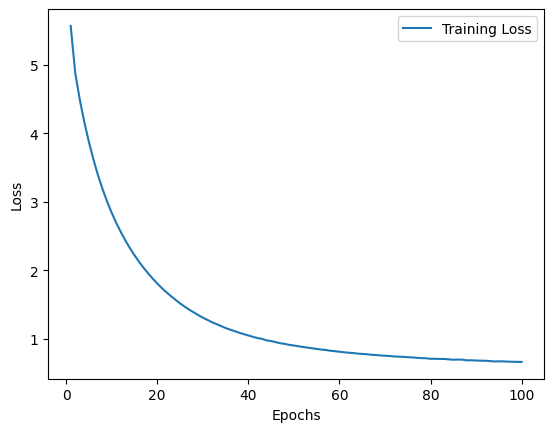

In [24]:
plt.plot(range(1,num_epochs+1) , losses ,label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#**Save the trained Model:**

In [25]:
model_path='/content/drive/MyDrive/lstm_model2321.pth'
torch.save(model.state_dict(),model_path)

## **Evaluation:**

We define a function for each generation strategies to experiment with our trained model and determine which approach yields the best generation results.

1) **sample_with_temperature:** uses temperature sampling strategy <br>
- This method scales the model's output logits by a temperature factor before converting them into probabilities.
- A lower temperature sharpens the probability distribution , making the model more deterministic (it tends to select the most likely token).
- A higher temperature smooths the distribution , introducing more randomness and diversity in the generated text.

2) **sample_with_top_p:** uses Top_P (Nucleus) sampling strategy<br>
- This strategy sorts the tokens by their probability and accumulates them until the total probability exceeds a predefined threshold (top_p).

-  Only the tokens within this cumulative probability mass are considered for sampling.

- By dynamically adjusting the set of candidate tokens, this method balances between creativity and coherence, excluding very unlikely tokens while not limiting the number of choices strictly.



3) **sample_with_top_k:** uses Top_K sampling strategy . <br>

- Here, the model only considers the top k tokens with the highest probabilities, ignoring the rest.

- This fixed-size restriction ensures that only the most likely tokens are sampled from, which can help maintain relevance and fluency in the generated text.

- The randomness is confined to a smaller, controlled subset of options, often leading to more focused output.





In [26]:
# Functions to generate lyrics with different strategies


def sample_with_temperature(predictions , temperature=0.8):

  # scale the predictions by the temperature
  predictions=predictions/temperature
  # convert to probabilities using softmax
  probabilities=torch.nn.functional.softmax(predictions,dim=0)
  # sample a random token from the probabilty
  return torch.multinomial(probabilities,1).item()


def sample_with_top_p(prediction, top_p=0.92):

   # sort the prediction scores in descending order
   sorted_indx=torch.argsort(prediction,descending=True)
   # apply softmax to get probabilities
   sorted_prob=torch.nn.functional.softmax(prediction[sorted_indx],dim=0)

   # compute the cumulative probabilities
   cum_prop=torch.cumsum(sorted_prob.view(-1, sorted_prob.shape[0]),dim=0)
   # filter indices to only include toknes with cum_prop less or equal to top_p
   filtered_indx=sorted_indx[cum_prop[0] <= top_p]
   if len(filtered_indx)==0:
    filtered_indx=sorted_indx

   # Adjust the indexing to work with the modified cum_prop and randomly pick a token from the filtered_indx
   selected_indx=filtered_indx[torch.multinomial(sorted_prob[:len(filtered_indx)],1)].item()

   return selected_indx


def sample_with_top_k(prediction,top_k=5):

   # compute probabilities over the prediction scores
   probabilities=torch.softmax(prediction,dim=-1)
   # select the top_k prob and their corresponding indices.
   top_k_probs, top_k_indx=torch.topk(probabilities,k=top_k)
   # randomly sample from the top_k probabilities
   sampled_indx=torch.multinomial(top_k_probs,1).item()
   next_token=top_k_indx[sampled_indx].item()

   return next_token

#**Define Generation function:** <br>

We define the function **LyricsGenerator** to generate new lyrics using the trained LSTM model by strating with a given string and generating tokens until it reache the average words count using the different token sampling strategies  we defined above.


In [562]:
def LyricsGenerator(starting_string , max_count , strategy="greedy", temperature=1.3 , top_k=5 , top_p=0.92):

  model.eval()

  if not starting_string:
    possible_words=[w for w in word_to_index.keys() if w not in ["<UNK>","<PAD>"]]
    starting_string=random.choice(possible_words)




  # Initialize the oputput with the strating string
  output=starting_string

  # Initialize hidden state for the LSTM
  hidden= None

  # convert the strating string to a list of indices using the vocabulary mapping.
  current_input=torch.tensor([word_to_index.get(token,word_to_index["<UNK>"])
                              for token in re.findall(r"\S+|\n" ,starting_string)])


  current_input=current_input.unsqueeze(0).to(device)

  with torch.no_grad():

    # process each token from the strating string to update the hidden state
    for token in current_input[0]:

      _,hidden=model(token.unsqueeze(0).unsqueeze(0))

    # Set tha last token as the current token (if starting string is empty we choose  use <PAD> token)
    current_token= current_input[0,-1] if current_input.numel()>0 else torch.tensor(word_to_index["<PAD>"]).to(device)


    # Generate tokens until output reaches max_count tokens.
    while len(output) < max_count:

      # Get predictions for the next token
      current_input=current_token.unsqueeze(0).unsqueeze(0)
      logits,hidden=model(current_input,hidden)
      predictions=logits.squeeze()

     # Select the next token based on the chosen strategy
      if strategy=="temperature":
        next_token=sample_with_temperature(predictions,temperature=temperature)

      elif strategy=="top_p":
        next_token=sample_with_top_p(predictions,top_p=top_p)

      elif strategy=="top_k":

        next_token=sample_with_top_k(predictions,top_k=top_k)

      else:
        # Greedy strategy : choose the token with higest probabilty .
        next_token=torch.argmax(predictions).item()

      # convert the selected token index back to word
      next_word= index_to_word.get(next_token,"<UNK>")

      # Append the generated word to the output string
      output+=" "+ next_word
      # set the current token for the next iteration
      current_token=torch.tensor(next_token).to(device)

  # return the generated lyrics
  return output




#**Generated Song 1:**

 **Song 1 : start with "It's not a silly little moment ..."**

 we experiment with all the generation startegy we defined above with differnt parmaeters and here is an example of  some the generated lyrics we get :<br>


1) Temperature sampling:

we tried temperature values between 0.8 and 1.3 :<br>

*   temperature=0.8:
```
 it's not a silly little moment ... younger human street woo
 it wasn't much to sleep but it's a cold
 but i've got gotta just nothing gotta fight
 down on the start out of blue
 don't believe in times
 you can never lose the show
 and you're looking for
 don't forget abouboubouboubout
```

Produces more coherent but less creative lyrics (e.g., "it's not a silly little moment ... younger human street woo").


*   temperature=1.1:
```
it's not a silly little moment ... younger human street ohoh
 i've loved you can't let me hold you
 let me die let me die
 let me feel your own life hey baby than we can let us get together someday
 we're getting under it oh baby you're all gone wrong
 gone yeah you're happy
  in their finger
```

Introduces more creativity and variability but may sacrifice coherence (e.g., "let me die let me die let me feel your own life hey baby").



2) Tob-k Sampling:



*   top_k=5:
```
 it's not a silly little moment ... growin' five eell yeah yeah
 yeah the surprise we're just a little great in a play when you're out for you baby oh oh
 but i'm falling a baby ain't this time
 maybe tomorrow i'll get a chance
 still i'm asking that i'm here for the time yeah
```

  Produces more focused and coherent lyrics but may lack diversity (e.g., "it's not a silly little moment ... growin' five eell yeah yeah").

*   top_k=10:
```
it's not a silly little moment ... younger human street ohoh
 that man i showed up at your party times ah
 i still on my knees where you belong
 i say let's go where i go
 when morning those days of darkness
 of every time they painted
 and all the people in love but when
```

  Introduces more variability while maintaining coherence (e.g., "it's not a silly little moment ... younger human street ohoh").

3) Top_p ( Nucleus) Sampling:


we tried p values between 0.9 to 0.95
    
*   p=0.9:
```
 it's not a silly little moment ... growin' five eell and take take off yeah
 i love someone so joy and telling myself right the road to me and we'll understand you should go if a fight like that oh yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah yeah
```

  Produces more conservative and repetitive outputs (e.g., "it's not a silly little moment ... growin' five eell and take take off yeah").

*   p=0.94:
```
 it's not a silly little moment ... growin' stuck forever baby
 i'm a good boy i'm for good to be so
 you're not too slow for being to get angel
 sometimes is a devil as there don't seem at wrong now oh god i'm not there
 i'm your kind of man i'm no dancer mmm yeah yeah yeah
```

  Introduces more diversity and creativity while maintaining coherence (e.g., "it's not a silly little moment ... growin' stuck forever baby").




4) Gready sampling :<br>

```
 it's not a silly little moment ... younger human street ohoh
 that man i showed my hands on his face
 a love you gave me a whole time
 met a fire so put for his music zone and watch the evening by the wall
 the summer the way i saw you the line you were the best of
 every
```

we can see that Greedy sampling give us clear and straightforward text but lack from creative varability like the other stratiges.



So , From observing the results we can see that for Top_k sampling with k=10 and Temp


In [637]:
print("Generated Song 1:\n")

# Using temperature sampling :
generated_lyrics_temp = LyricsGenerator("it's not a silly little moment ...",
                                        max_count=int(avg_word), strategy="temperature", temperature=1.1)

# Using top-k sampling :
generated_lyrics_topk = LyricsGenerator("it's not a silly little moment ...",
                                        max_count=int(avg_word), strategy="top_k", top_k=10)

# # Using top-p sampling :
# generated_lyrics_topp = LyricsGenerator("it's not a silly little moment ...",
#                                         max_count=int(avg_word), strategy="top_p", top_p=0.92)

# generated_greedy=LyricsGenerator("it's not a silly little moment ...",
#                                         max_count=int(avg_word), strategy="greedy")

print("\n\nTemperature Sampling:\n\n", generated_lyrics_temp)
print("\n\nTop-k Sampling:\n\n", generated_lyrics_topk)
# print("\nTop-p Sampling:\n", generated_lyrics_topp)
# print("\nGreedy Sampling:\n", generated_greedy)


Generated Song 1:



Temperature Sampling:

 it's not a silly little moment ... younger my workin' true 
 been so long been too late 
 heaven round from tears and some first smile 
 which can come along our lives is gone 
 a man who can wait like an altar 
 but in passing there 
 on desolation row at you 
 late at her death


Top-k Sampling:

 it's not a silly little moment ... younger human street 
 from all the women shall be certain 
 the first one has been loved 
 but the restlessness was broken 
 for the folks that he found the same 
 her folks who am the rivers jar in 
 that he loved her 
 he just can't wait and


#**Generated Song 2:**

```

Temperature Sampling:
 Hello, it's me herself girl
 oh save me save me
 let me save let me go alone
 if you push some can be her room
 i'm gonna feel the rain
 i'm lost here in the flame
 i'm gonna living on
 let's go outside at all
 and my angel is my fiddle in my hair
 while my place to find

Top-k Sampling:
 Hello, it's me loneliness outta night
 oh it seems in my time in me and tremble to two
 and love is all alone you know
 why should i imagine that my brother would you
 this clique was really dying other
 between you
 everywhere you could stay
 and she's so swishy in a darkness

Top-p Sampling:
 Hello, it's me herself
 oh tell my heart that's my baby do your lover i'm home for you ooh don't sit alone hey no good no hey hey oh oh oh no
 she's only gonna love this make a thing
 learned i'll fly them better farm oh yeah
 you got it for it's sacred today than we are all

Greedy Sampling:
 Hello, it's me herself girl
 oh save me
 oh
 oh
 oh
 oh yeah
 oh
 oh
 oh yeah
 feels like over
 oh yeah
 it feels like it's enough
 it's a bit of broken as a surprise
 it's like you can't trust
 and everybody knows that your heart turns out hot to jail
 'cause you

```






In [642]:
print("Generated Song 2:\n")
# Using temperature sampling :
generated_lyrics_temp = LyricsGenerator("Hello, it's me",
                                        max_count=int(avg_word), strategy="temperature", temperature=1.1)

# Using top-k sampling :
generated_lyrics_topk = LyricsGenerator("Hello, it's me",
                                        max_count=int(avg_word), strategy="top_k", top_k=10)

# Using top-p sampling :
# generated_lyrics_topp = LyricsGenerator("Hello, it's me",
#                                         max_count=int(avg_word), strategy="top_p", top_p=0.92)

# generated_greedy=LyricsGenerator("Hello, it's me",
#                                         max_count=int(avg_word), strategy="greedy")

print("\nTemperature Sampling:\n\n", generated_lyrics_temp)
print("\n\nTop-k Sampling:\n\n", generated_lyrics_topk)
# print("\nTop-p Sampling:\n", generated_lyrics_topp)
# print("\nGreedy Sampling:\n", generated_greedy)


Generated Song 2:


Temperature Sampling:

 Hello, it's me herself 
 let me know you never know 
 you may have bad 
 'cause i can't trace things 
 and i may be part of me and me 
 i don't wanna know about your new man 
 'cause if it just feel wonderful would be so cold 
 and i don't wanna know what you've done 
 never be


Top-k Sampling:

 Hello, it's me herself girl 
 oh save me 
 don't know now it's good for 
 take my wonder and 
 can never know how to go insane 
 say goodbye to help it be 
 and i'll never know how much i can find 
 take my eyes and smile 
 can you save my knees back home 
 i've got my nothing


#**Generated Song 3:**




```

Temperature Sampling:
 we're back there's secret
 don't major these words to stand in my head
 lay down sally when you need yourself apart
 i've been losin' high or nights in run
 well run out on a different point of mind
 i'm so high and this dancer true oohooh
 i'll run like you can ride me

Top-k Sampling:
 dog's desert baby moved me school
 well maybe rap will you realize we go cold and me oh
 well we will only young and for the last time
 we could not come back just for time
 of desmond and some take my heart which we do we
 we should know where to find know we can know to

Top-p Sampling:
 bandito didnt laughed england's woo woo mmm ooh hey hey hey hey
 hey hey hey hey hey
 make a warm way by and just it any way
 passed by home a make where kiss me by
 another one by the tree
 ohoh ohoh life of golden soul o blue
 one broken life without another body in your

Greedy Sampling:
 paintings who are time of something one
 the kids was quite spirit
 we made it out to the sea
 we were a singer with the right jeans
 just as sure that we ever loved this way
 they say
 we all go down in the clouds
 we always walked this three foot real oh
 we had a learned
```


















In [793]:
print("Generated Song 3:\n")
# Using temperature sampling :
generated_lyrics_temp = LyricsGenerator("",max_count=int(avg_word), strategy="temperature", temperature=1.1)


# Using top-k sampling :
generated_lyrics_topk = LyricsGenerator("",max_count=int(avg_word), strategy="top_k", top_k=10)

# Using top-p sampling :
# generated_lyrics_topp = LyricsGenerator("",max_count=int(avg_word), strategy="top_p", top_p=0.92)

# generated_greedy=LyricsGenerator("",max_count=int(avg_word), strategy="greedy")


print("Temperature Sampling:\n\n", generated_lyrics_temp)
print("\n\nTop-k Sampling:\n\n", generated_lyrics_topk)
# print("\nTop-p Sampling:\n", generated_lyrics_topp)
# print("\nGreedy Sampling:\n", generated_greedy)

Generated Song 3:

Temperature Sampling:

 lots of me and you 
 but know it's here for here and it's hounded you 
 and there's no way out of her new fool 
 you're in your worst shoes 
 i'm the best i hear my heart finds 
 mine can you leave me down down 
 lord right boy save me you do 
 can you do now you do 
 i'm standing


Top-k Sampling:

 besides screams spoon goes kindness day children nights day 
 start a girl with a little stars 
 only one by my one 
 take me home and the church on your eyes 
 te amo mami in the stranger 
 play another match now and i'm alone at the stars 
 won't you take your hand on my cheek


# **MODEL - SUMMARY :**

In [581]:
# Print the network summary
print(model)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(model)

print(f'Total trainable parameters: {total_params}')

LSTMModel(
  (embedding): Embedding(9651, 100)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=9651, bias=True)
)
Total trainable parameters: 2459935
